## Import modules/packages

In [1]:
import numpy as np
import keras

from util import random_sine, plot_prediction

## Hyperparameters and model configuration
This model uses a Gated Recurrent Unit (GRU). Other units (LSTM) would also work with a few modifications to the code.

In [2]:
keras.backend.clear_session()

layers = [35, 35] # Number of hidden neuros in each layer of the encoder and decoder

learning_rate = 0.01
decay = 0 # Learning rate decay
optimiser = keras.optimizers.Adam(learning_rate=learning_rate, decay=decay) # Other possible optimiser "sgd" (Stochastic Gradient Descent)

num_input_features = 1 # The dimensionality of the input at each time step. In this case a 1D signal.
num_output_features = 1 # The dimensionality of the output at each time step. In this case a 1D signal.
# There is no reason for the input sequence to be of same dimension as the ouput sequence.
# For instance, using 3 input signals: consumer confidence, inflation and house prices to predict the future house prices.

loss = "mse" # Other loss functions are possible, see Keras documentation.

# Regularisation isn't really needed for this application
lambda_regulariser = 0.000001 # Will not be used if regulariser is None
regulariser = None # Possible regulariser: keras.regularizers.l2(lambda_regulariser)

batch_size = 512
steps_per_epoch = 200 # batch_size * steps_per_epoch = total number of training examples
epochs = 15

input_sequence_length = 15 # Length of the sequence used by the encoder
target_sequence_length = 15 # Length of the sequence predicted by the decoder
num_steps_to_predict = 20 # Length to use when testing the model

num_signals = 2 # The number of random sine waves the compose the signal. The more sine waves, the harder the problem.

/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


## Create model

### Create encoder
The encoder is first created by instantiating a graph, which is a description of the operations applied
to the tensors (that will later hold the data).
This is common among many neural network frameworks.

In [3]:
# Define an input sequence.
encoder_inputs = keras.layers.Input(shape=(None, num_input_features))

# Create a list of RNN Cells, these are then concatenated into a single layer
# with the RNN layer.
encoder_cells = []
for hidden_neurons in layers:
    encoder_cells.append(keras.layers.GRUCell(hidden_neurons,
                                              kernel_regularizer=regulariser,
                                              recurrent_regularizer=regulariser,
                                              bias_regularizer=regulariser))

encoder = keras.layers.RNN(encoder_cells, return_state=True)

encoder_outputs_and_states = encoder(encoder_inputs)

# Discard encoder outputs and only keep the states.
# The outputs are of no interest to us, the encoder's
# job is to create a state describing the input sequence.
encoder_states = encoder_outputs_and_states[1:]
   

### Create decoder
The decoder is created similarly to the encoder

In [4]:
# The decoder input will be set to zero (see random_sine function of the utils module).
# Do not worry about the input size being 1, I will explain that in the next cell.
decoder_inputs = keras.layers.Input(shape=(None, 1))

decoder_cells = []
for hidden_neurons in layers:
    decoder_cells.append(keras.layers.GRUCell(hidden_neurons,
                                              kernel_regularizer=regulariser,
                                              recurrent_regularizer=regulariser,
                                              bias_regularizer=regulariser))

decoder = keras.layers.RNN(decoder_cells, return_sequences=True, return_state=True)

# Set the initial state of the decoder to be the ouput state of the encoder.
# This is the fundamental part of the encoder-decoder.
decoder_outputs_and_states = decoder(decoder_inputs, initial_state=encoder_states)

# Only select the output of the decoder (not the states)
decoder_outputs = decoder_outputs_and_states[0]

# Apply a dense layer with linear activation to set output to correct dimension
# and scale (tanh is default activation for GRU in Keras, our output sine function can be larger then 1)
decoder_dense = keras.layers.Dense(num_output_features,
                                   activation='linear',
                                   kernel_regularizer=regulariser,
                                   bias_regularizer=regulariser)

decoder_outputs = decoder_dense(decoder_outputs)

### Create model and compile

A notable detail here, are the inputs to the model. The train model has two inputs : encoder_inputs and decoder_inputs. What encoder_inputs should be is clear, the encoder_inputs should hold the input series. But what about the decoder inputs?

In machine translation applications (see "A ten minute introduction to sequence-to-sequence learning in keras") something called teacher forcing is used. In teacher forcing, the input to the decoder during training is the target sequence shifted by 1. This supposedly helps the decoder learn and is an effective method for machine translation. I tested teacher forcing for sequence prediction and the results were bad. I am not entirely sure why this is the case, my intuition is that unlike machine translation, if you feed the decoder the correct sequence shifted by one, your model becomes "lazy" because it only has to look at the value input in the step before and apply a small modification to it. In other words, the gradients of the truncated back propagation beyond the n-1 step will be very small and the model will develop a short memory. However, if the input to the decoder is 0, it forces the model to really memorize the values that are fed to the encoder since it has nothing else to work on. In some sense, teacher forcing might artificially induce vanishing gradients.

I suggest you look into the random_sine function of the utils module of this repository. You will see the the decoder input is simply set to zero. You may be asking yourselves why the decoder has an input if it's set to zero...The reason is simple, Keras RNNs must take an input value.

In [5]:
# Create a model using the functional API provided by Keras.
# The functional API is great, it gives an amazing amount of freedom in architecture of your NN.
# A read worth your time: https://keras.io/getting-started/functional-api-guide/ 
model = keras.models.Model(inputs=[encoder_inputs, decoder_inputs], outputs=decoder_outputs)
model.compile(optimizer=optimiser, loss=loss)


## Fit model to data
I like using the fit_generator in Keras. In this case it's not really useful/necessary since my training examples easily fit into memory. In cases when the training data doesn't fit into memory, the fit_generator is definitely the way to go.
A standard python generator is usually fine for the fit_generator function, however, Keras provides a nice class keras.utils.Sequence that you can inherit from to create your own generator. This is a requirement to guarantee that the elements of the generator are only selected once in the case of multiprocessing (which isn't guaranteed with the standard generator). A simple example of using the data generators in Keras is ["A detailed example of how to use data generators with Keras"](https://stanford.edu/~shervine/blog/keras-how-to-generate-data-on-the-fly.html) by Shervine Amidi.

In [6]:
# random_sine returns a generator that produces batches of training samples ([encoder_input, decoder_input], decoder_output)
# You can play with the min max frequencies of the sine waves, the number of sine waves that are summed etc...
# Another interesing exercise could be to see whether the model generalises well on sums of 3 signals if it's only been
# trained on sums of 2 signals...
train_data_generator = random_sine(batch_size=batch_size,
                                   steps_per_epoch=steps_per_epoch,
                                   input_sequence_length=input_sequence_length,
                                   target_sequence_length=target_sequence_length,
                                   min_frequency=0.1, max_frequency=10,
                                   min_amplitude=0.1, max_amplitude=1,
                                   min_offset=-0.5, max_offset=0.5,
                                   num_signals=num_signals, seed=1969)


model.fit(train_data_generator, steps_per_epoch=steps_per_epoch, epochs=epochs)

Epoch 1/15


/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_4']. Received: the structure of inputs=('*', '*')
  warnings.warn(


200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3218
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.1744
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0886
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0601
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0484
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0406
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0361
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0322
Epoch 9/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0296
Epoch 10/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0283
Epoch 11/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0268
Epoch 12/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0252
Epoch 13/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0241
Epoch 14/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0234
Epoch 15/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step 

It is now possible to use this model to make predictions:

In [7]:
test_data_generator = random_sine(batch_size=1000,
                                  steps_per_epoch=steps_per_epoch,
                                  input_sequence_length=input_sequence_length,
                                  target_sequence_length=target_sequence_length,
                                  min_frequency=0.1, max_frequency=10,
                                  min_amplitude=0.1, max_amplitude=1,
                                  min_offset=-0.5, max_offset=0.5,
                                  num_signals=num_signals, seed=2000)

(x_encoder_test, x_decoder_test), y_test = next(test_data_generator) # x_decoder_test is composed of zeros.

y_test_predicted = model.predict([x_encoder_test, x_decoder_test])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


A limitation of using this model to make the predictions is that we can only predict a sequence of same length as the training data. This can be a problem if we want to predict less or more than the training sequence lengths.
In the next section I will show how to create "prediction" models that allow to predict sequences of arbitrary length.

## Create "prediction" models

When using the encoder-decoder to predict a sequence of arbitrary length, the encoder first encodes the entire input sequence. The state of the encoder is then fed to the decoder which then produces the output sequence sequentially.
Although a new model is being created with the keras.models.Model class, the input and output tensors of the model are the same as those used during training, hence the weights of the layers applied to the tensors are preserved.

As you will see, creating the prediction models also gives the ability to inspect the state of the model at different points throughout the prediction process. We could study how the encoder creates a representation of the input data. For instance, how does the model represent the offset? Or the frequency? Does it decompose the signal into it's constituent sine waves and represent them as different dimensions of the state vector? These are very interesting questions for another time.

In [8]:
encoder_predict_model = keras.models.Model(encoder_inputs,
                                           encoder_states)

decoder_states_inputs = []

# Read layers backwards to fit the format of initial_state
# For some reason, the states of the model are order backwards (state of the first layer at the end of the list)
# If instead of a GRU you were using an LSTM Cell, you would have to append two Input tensors since the LSTM has 2 states.
for hidden_neurons in layers[::-1]:
    # One state for GRU
    decoder_states_inputs.append(keras.layers.Input(shape=(hidden_neurons,)))

decoder_outputs_and_states = decoder(
    decoder_inputs, initial_state=decoder_states_inputs)

decoder_outputs = decoder_outputs_and_states[0]
decoder_states = decoder_outputs_and_states[1:]

decoder_outputs = decoder_dense(decoder_outputs)

# decoder_predict_model = keras.models.Model(
#         [decoder_inputs] + decoder_states_inputs,
#         [decoder_outputs] + decoder_states)

decoder_predict_model = keras.models.Model(
    inputs=[decoder_inputs] + decoder_states_inputs,
    outputs=[decoder_outputs] + [state for state in decoder_outputs_and_states[1:]]
)

In [9]:
# Let's define a small function that predicts based on the trained encoder and decoder models

def predict(x, encoder_predict_model, decoder_predict_model, num_steps_to_predict):
    """Predict time series with encoder-decoder.
    
    Uses the encoder and decoder models previously trained to predict the next
    num_steps_to_predict values of the time series.
    
    Arguments
    ---------
    x: input time series of shape (batch_size, input_sequence_length, input_dimension).
    encoder_predict_model: The Keras encoder model.
    decoder_predict_model: The Keras decoder model.
    num_steps_to_predict: The number of steps in the future to predict
    
    Returns
    -------
    y_predicted: output time series for shape (batch_size, target_sequence_length,
        ouput_dimension)
    """
    y_predicted = []

    # Encode the values as a state vector
    states = encoder_predict_model.predict(x)

    # The states must be a list
    if not isinstance(states, list):
        states = [states]

    # Generate first value of the decoder input sequence
    decoder_input = np.zeros((x.shape[0], 1, 1))


    for _ in range(num_steps_to_predict):
        outputs_and_states = decoder_predict_model.predict(
        [decoder_input] + states, batch_size=batch_size)
        output = outputs_and_states[0]
        states = outputs_and_states[1:]

        # add predicted value
        y_predicted.append(output)

    return np.concatenate(y_predicted, axis=1)
    

In [10]:
# The aim of this tutorial isn't to present how to evaluate the model or investigate the training.
# We could plot evaluation metrics such as RMSE over time, compare train and test batches for overfitting,
# produce validation and learning curves to analyse the effect of the number of epochs or training examples,
# have fun playing with tensorboard etc... We would need at least a whole other post for this.
# However, let's at least make sure that our model can predict correctly...
# Ask the generator to produce a batch of samples, don't forget to set the seed to something other than what was
# used for training or you will be testing on train data.
# The next function asks the generator to produce it's first batch.

test_data_generator = random_sine(batch_size=1000,
                                  steps_per_epoch=steps_per_epoch,
                                  input_sequence_length=input_sequence_length,
                                  target_sequence_length=target_sequence_length,
                                  min_frequency=0.1, max_frequency=10,
                                  min_amplitude=0.1, max_amplitude=1,
                                  min_offset=-0.5, max_offset=0.5,
                                  num_signals=num_signals, seed=2000)

(x_test, _), y_test = next(test_data_generator)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_4', 'keras_tensor_9', 'keras_tensor_10']. Received: the structure of inputs=('*', ('*', '*'))
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/stepWARNING:tensorflow:6 out of the last 36 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x31155d1c0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/Users/rr/Documents/Diajeng/TA/program/progress_ta/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_4', 'keras_tensor_9', 'keras_tensor_10']. Received: the structure of inputs=('*', '*', '*')
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


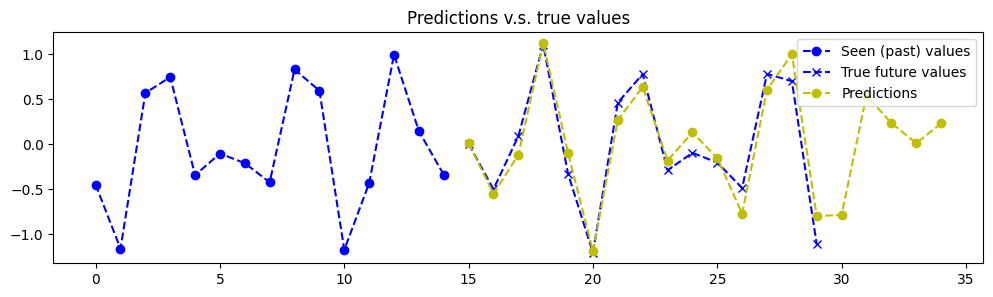

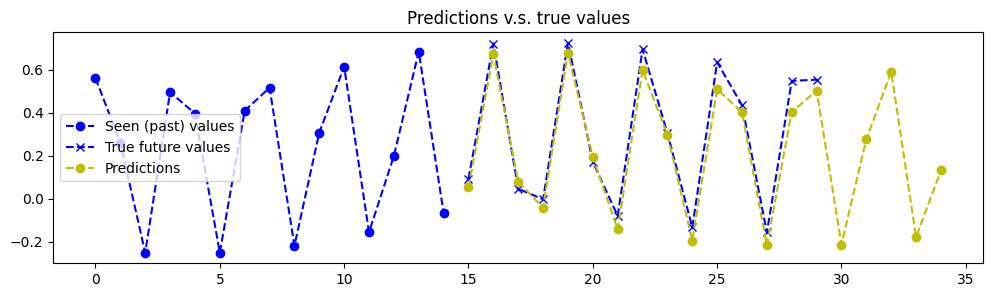

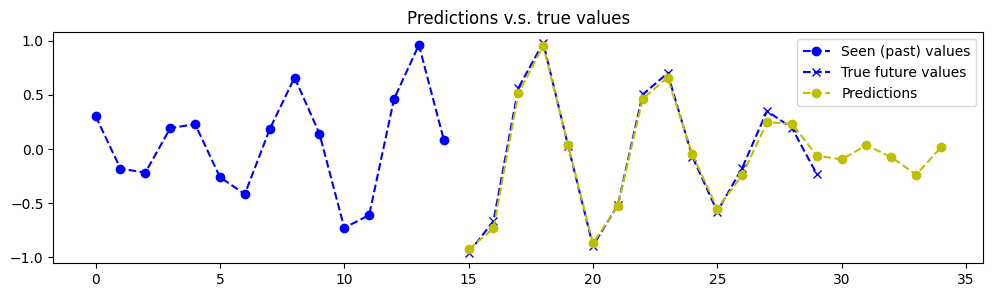

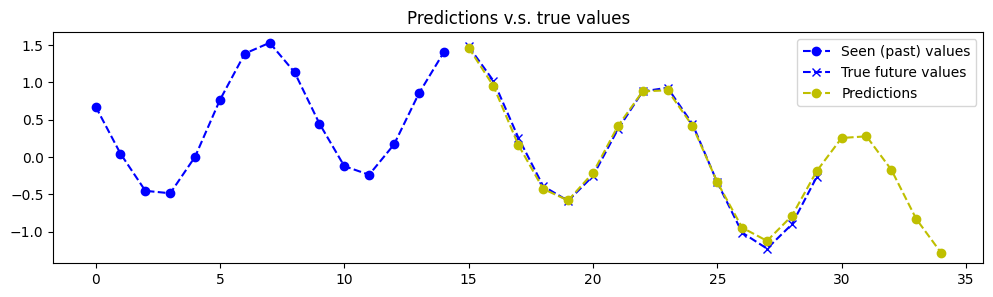

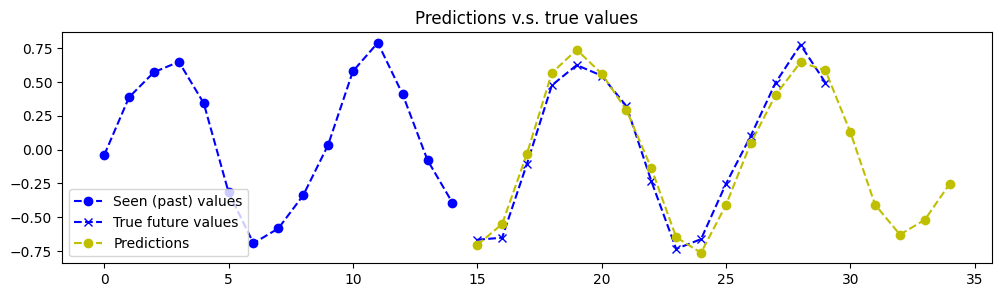

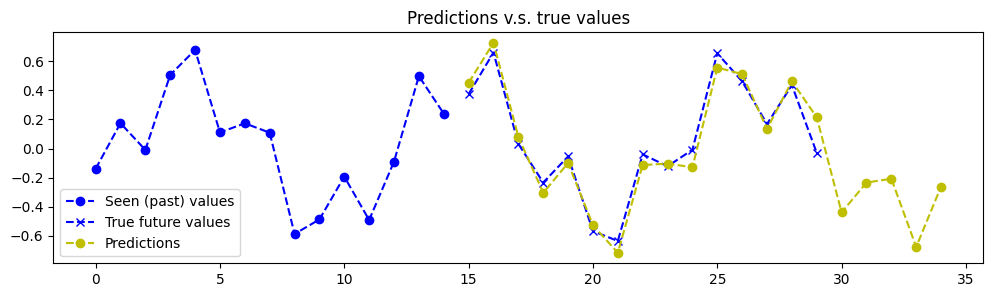

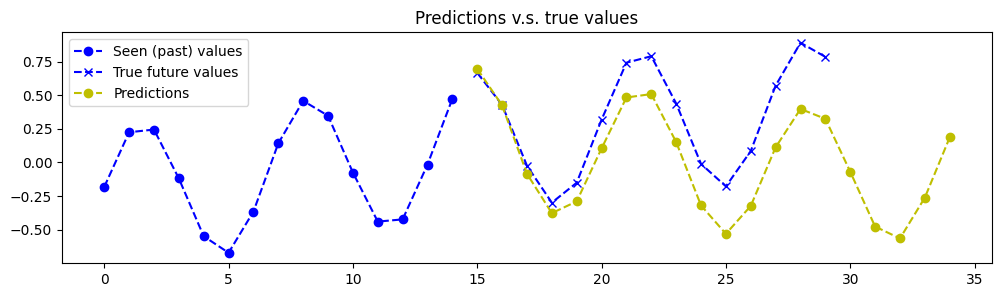

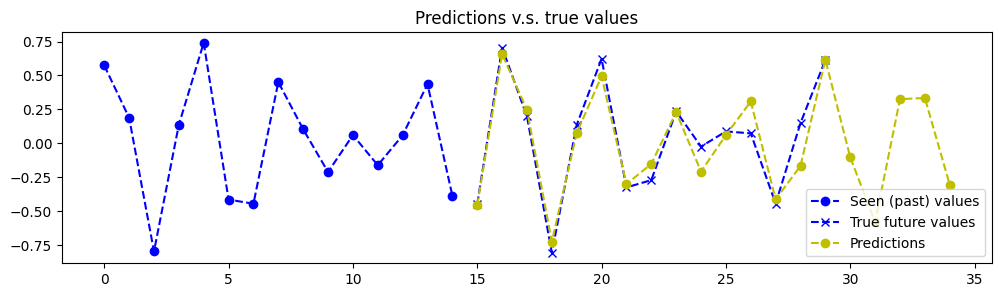

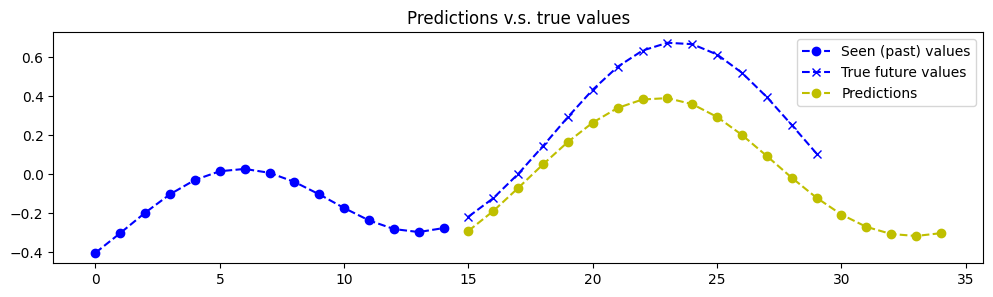

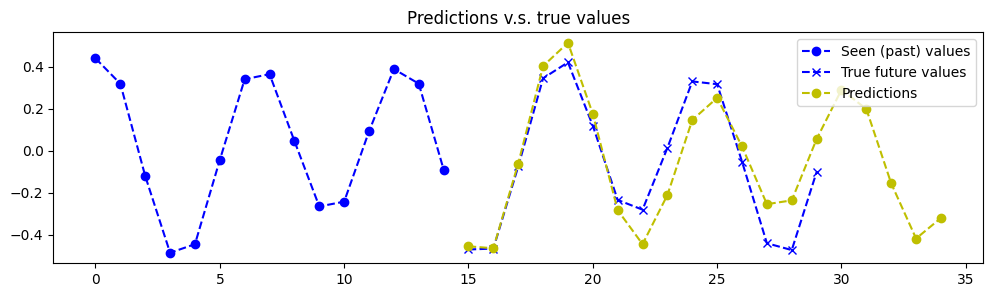

In [11]:
y_test_predicted = predict(x_test, encoder_predict_model, decoder_predict_model, num_steps_to_predict)

# Select 10 random examples to plot
indices = np.random.choice(range(x_test.shape[0]), replace=False, size=10)


for index in indices:
    plot_prediction(x_test[index, :, :], y_test[index, :, :], y_test_predicted[index, :, :])
    
# The model seems to struggle on very low wave signals. But that makes sense, the model doesn't see enough of the signal
# to make a good estimation of the frequency components.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 942us/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


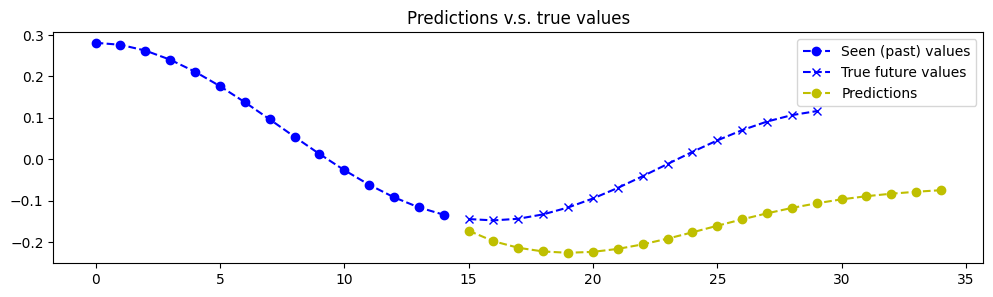

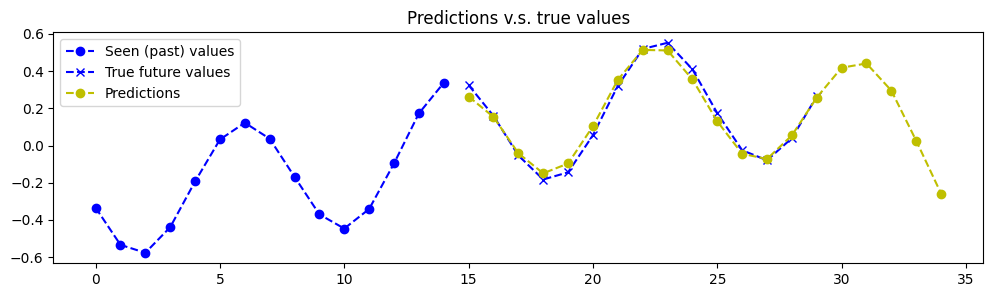

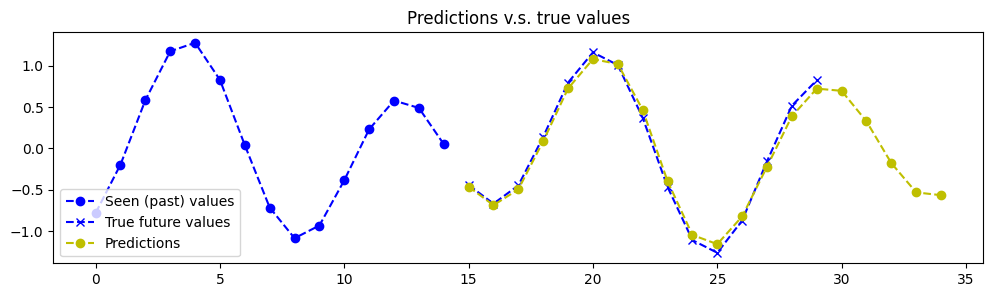

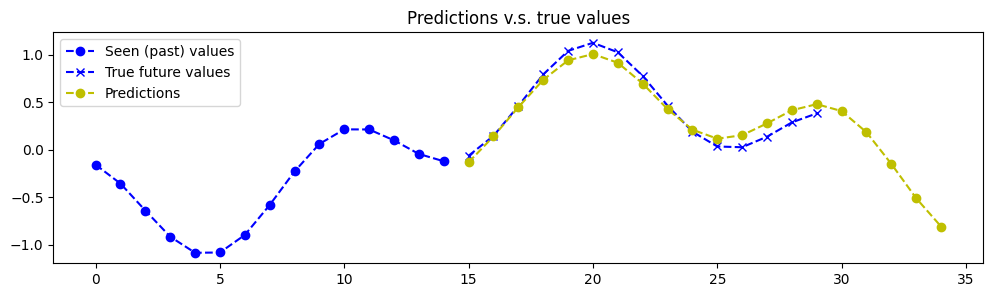

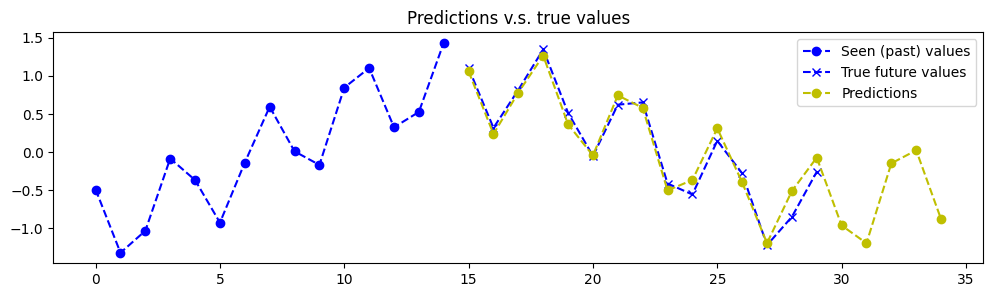

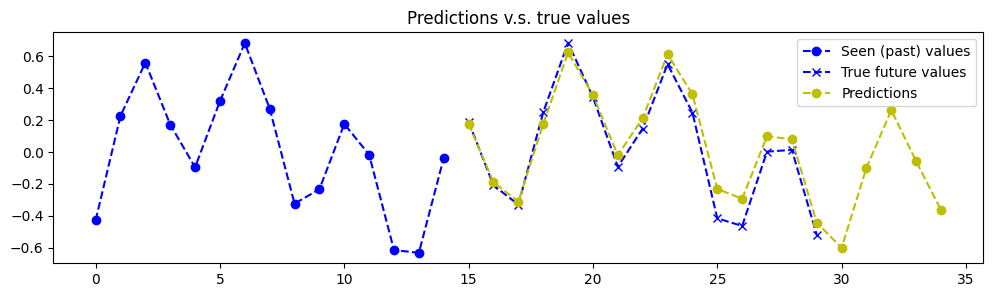

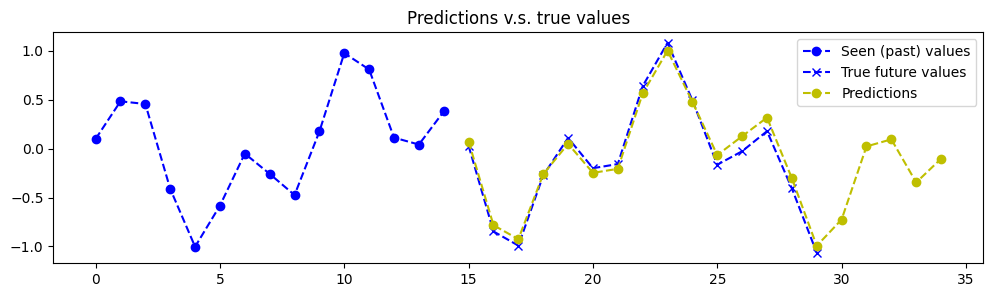

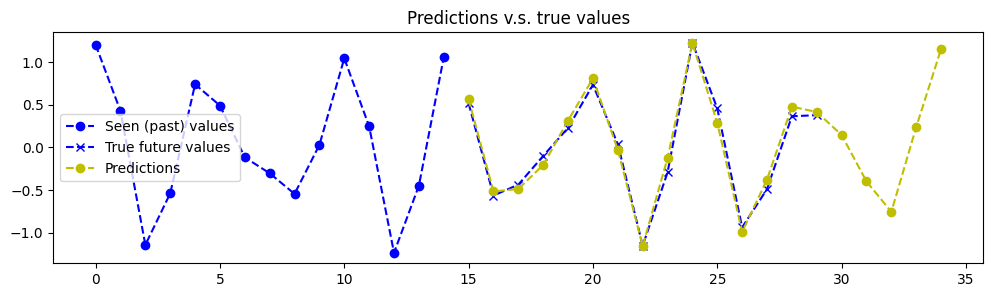

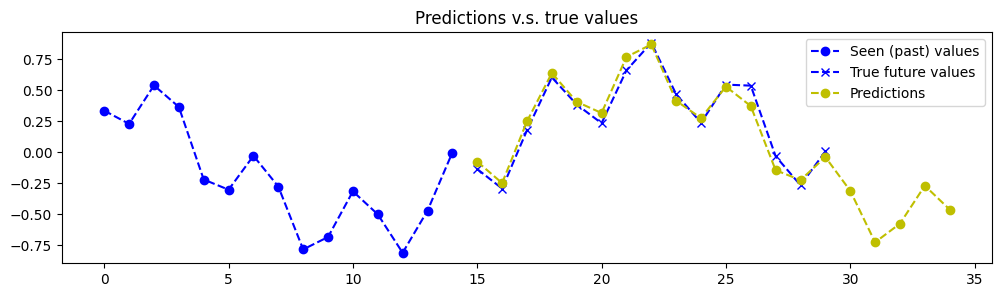

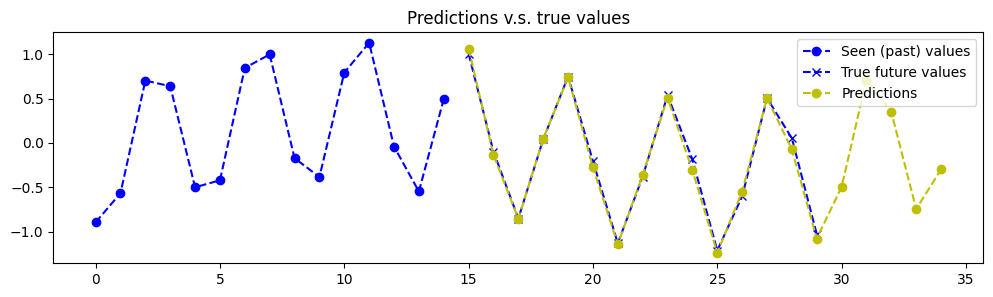

In [12]:
train_data_generator = random_sine(batch_size=1000,
                                   steps_per_epoch=steps_per_epoch,
                                   input_sequence_length=input_sequence_length,
                                   target_sequence_length=target_sequence_length,
                                   min_frequency=0.1, max_frequency=10,
                                   min_amplitude=0.1, max_amplitude=1,
                                   min_offset=-0.5, max_offset=0.5,
                                   num_signals=num_signals, seed=1969)

(x_train, _), y_train = next(train_data_generator)

y_train_predicted = predict(x_train, encoder_predict_model, decoder_predict_model, num_steps_to_predict)

# Select 10 random examples to plot
indices = np.random.choice(range(x_train.shape[0]), replace=False, size=10)

for index in indices:
    plot_prediction(x_train[index, :, :], y_train[index, :, :], y_train_predicted[index, :, :])

## Next steps & Discussion

There are many things that could be done to either extend or improve this model. Here are a few ideas.

* There's no reason why the encoder and decoder should have the same complexity or the same number of layers. As well as doing a simple hyper parameter search, it could be interesting to implement a model with different encoder and decoder sizes. To do this, one would have to add a dense layer after retrieving the states of the encoder to transform them into the correct size.
* Encapsulate the encoder-decoder by creating a class with a fit/predict interface. This is actually something I have done, it's extremely useful as it allows to instantiate seq2seq models as easily as one would instantiate a scikit learn model.
* Add the ability to add context vectors to the state output by the encoder. The encoder is able to produce an input vector for the decoder based on the time series. It is possible to add constant features to the model by duplicating them at each input timestep. However, adding the ability to extend the encoder output state with a constant vector that represents context might also be a good idea (for example, if you're predicting the evolution of housing prices, you might want to tell your model which geographical area you are in, since prices might not evolve in the same manner depending on location). This is not the attention mechanism often used in NLP that also produces what is called a context vector(a context vector that is updated at each step of the decoder). But since adding attention to NLP seq2seq applications has hugely improved state of the art. It might also be worth looking into attention for sequence prediction.
* As described above, study how the encoder creates a representation of the input sequence by looking at the state vector.
* It appears that our model struggles on signals that have low frequency, one explanation might be that the model must "see" at least a certain number of periods to determine the frequency of the signal. An interesting questions to answer might be: How many periods of the constituent signals are required for the model to be accurate?
* Although our model was only train on an output sequence of length 15, it appears to be able to predict beyond that limit, this is something we can exploit with the prediction models.